# CTC pseudo error mask

This notebook compares the baseline greedy token at each frame with the best CTC forced-alignment path for the reference. A value of `1` marks a frame where the two paths differ.

In [6]:
import os
import sys

import matplotlib.pyplot as plt
import torch
import torchaudio

PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "..")
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from srcs.datasets.vicocktail import Collator, load_vicocktail
from srcs.nets.e2e import get_model
from srcs.nets.utils import ctc_decode, load_weights
from srcs.spm.spm_train import ensure_unigram
from srcs.spm.text_transofm import TextTransform

CHECKPOINT_PATH = os.path.join(
    PROJECT_ROOT, "checkpoints", "finetune_vsr_12", "final"
)
SAMPLE_INDEX = 500
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_dataset = load_vicocktail(splits=("test",))["test"]
model_path, units_path = ensure_unigram()
text_transform = TextTransform(model_path, units_path)
collator = Collator(text_transform, "test")

baseline = get_model("auto-vsr", text_transform.vocab_size, size="large")
load_weights(baseline, CHECKPOINT_PATH)
baseline.to(DEVICE).eval()

batch = collator([test_dataset[SAMPLE_INDEX]])
videos = batch["videos"].to(DEVICE)
video_lengths = batch["video_lengths"].to(DEVICE)
target_length = int(batch["label_lengths"][0])
target = batch["labels"][0, :target_length].to(DEVICE)

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Sample index: {SAMPLE_INDEX}")
print(f"Reference: {text_transform.decode(target)}")

Device: cuda
Checkpoint: d:\projects\VietnameseVSR\checkpoints\finetune_vsr_12\final
Sample index: 500
Reference: mọi người thấy xung quanh biết chắc là khoai đang dưới quê phải không đừng có để ý nha


In [7]:
def ctc_forced_align(logits, target, blank_id=0):
    log_probs = logits.float().log_softmax(dim=-1).cpu().unsqueeze(0)
    targets = target.long().cpu().unsqueeze(0)
    input_lengths = torch.tensor([logits.size(0)], dtype=torch.long)
    target_lengths = torch.tensor([target.numel()], dtype=torch.long)

    alignments, scores = torchaudio.functional.forced_align(
        log_probs,
        targets,
        input_lengths=input_lengths,
        target_lengths=target_lengths,
        blank=blank_id,
    )
    return alignments[0], scores[0]

In [12]:
with torch.no_grad():
    outputs = baseline.get_contexts(videos, video_lengths)

In [14]:
outputs.keys()

dict_keys(['visual_features', 'h2', 'h4', 'encoder_features', 'logits', 'input_lengths'])

Prediction: mọi người hãy quanh mình nhận hỏi là nhiều không
Frames: 101
Mismatch frames: 16
Pseudo error rate: 15.84%
Alignment score: -84.24


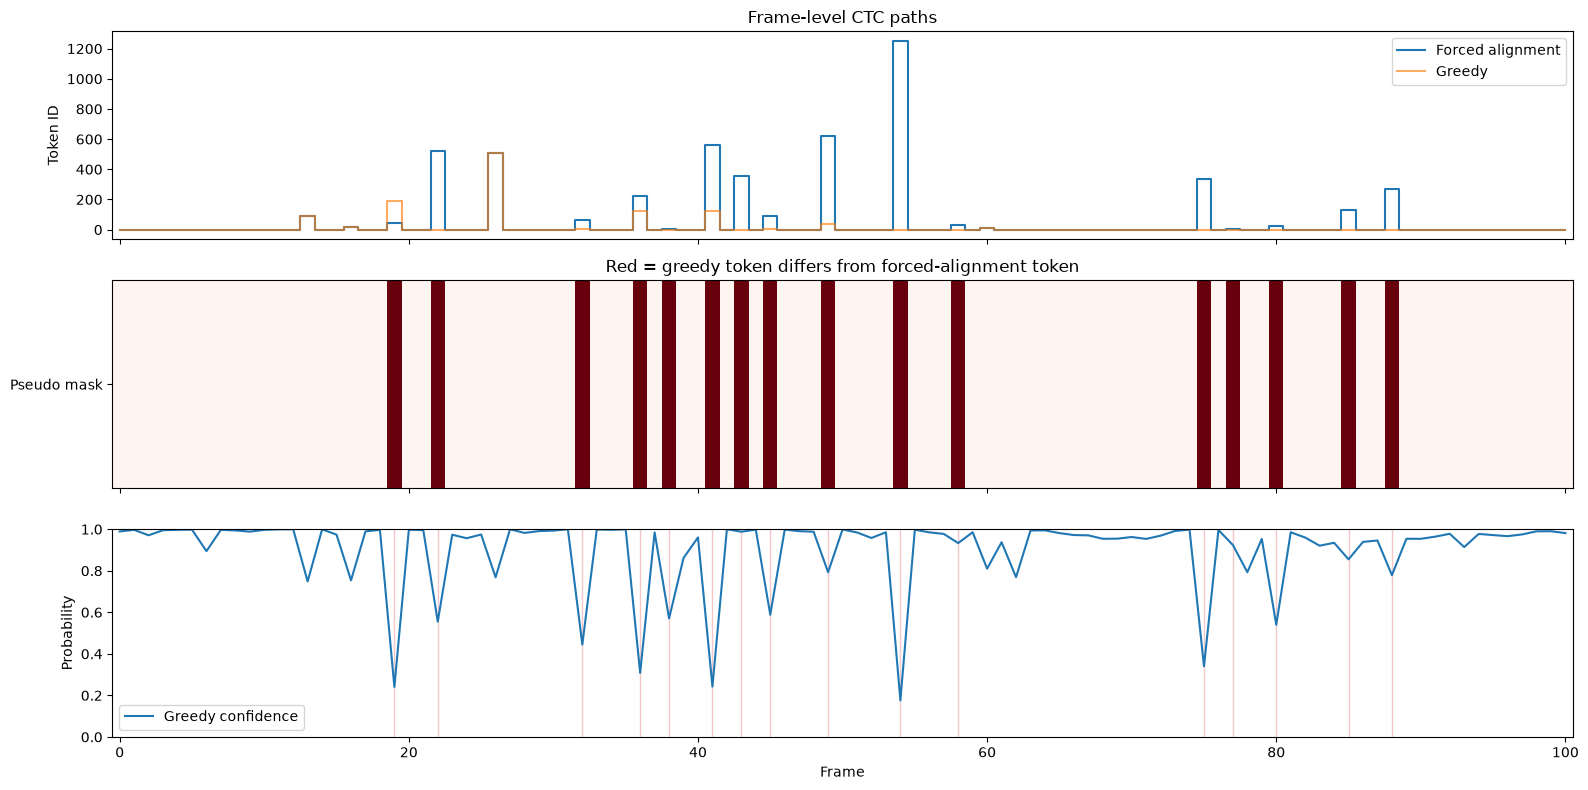

In [5]:
with torch.no_grad():
    outputs = baseline(videos, video_lengths)
    input_length = int(outputs["input_lengths"][0])
    logits = outputs["logits"][0, :input_length]
    alignment, alignment_scores = ctc_forced_align(
        logits, target, text_transform.blank_id
    )
    greedy = logits.argmax(dim=-1).cpu()
    err_label = greedy.ne(alignment).float()
    confidence = logits.softmax(dim=-1).amax(dim=-1)

prediction_ids = ctc_decode(
    greedy.unsqueeze(0),
    torch.tensor([input_length]),
    text_transform.blank_id,
)[0]

print(f"Prediction: {text_transform.decode(prediction_ids)}")
print(f"Frames: {input_length}")
print(f"Mismatch frames: {int(err_label.sum())}")
print(f"Pseudo error rate: {err_label.mean().item():.2%}")
print(f"Alignment score: {alignment_scores.sum().item():.2f}")

frames = torch.arange(input_length).cpu()
greedy_cpu = greedy.cpu()
alignment_cpu = alignment.cpu()
error_cpu = err_label.cpu()
confidence_cpu = confidence.cpu()

figure, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

axes[0].step(frames, alignment_cpu, where="mid", label="Forced alignment")
axes[0].step(frames, greedy_cpu, where="mid", alpha=0.65, label="Greedy")
axes[0].set_ylabel("Token ID")
axes[0].set_title("Frame-level CTC paths")
axes[0].legend()

axes[1].imshow(
    error_cpu.unsqueeze(0),
    cmap="Reds",
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="nearest",
)
axes[1].set_yticks([0], ["Pseudo mask"])
axes[1].set_title("Red = greedy token differs from forced-alignment token")

axes[2].plot(frames, confidence_cpu, color="tab:blue", label="Greedy confidence")
axes[2].fill_between(
    frames,
    0,
    1,
    where=error_cpu.bool(),
    color="tab:red",
    alpha=0.25,
    step="mid",
)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("Frame")
axes[2].set_ylabel("Probability")
axes[2].legend()

plt.tight_layout()
plt.show()

The pseudo mask is alignment-dependent. It also marks harmless CTC timing shifts and blank-placement differences, so it should not be interpreted as a direct word-error label without additional filtering.